# **Linear Regression Advertising**

In [1]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [2]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Print the last 5 rows
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [4]:
# Print the shape of the dataframe
df.shape

(200, 4)

In [5]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
# Data type of the attributes of the dataframe
df.dtypes

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [7]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [9]:
df.keys()

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [10]:
df.nunique()

,0
TV,190
Radio,167
Newspaper,172
Sales,121


In [11]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
TV,0,0.0
Radio,0,0.0
Newspaper,0,0.0
Sales,0,0.0


# **The dataset is clean with no duplicates and no missing values!**

In [13]:
df['TV'].value_counts()

,count
TV,
17.2,2
199.8,2
240.1,2
237.4,2
177.0,2
...,...
149.7,1
38.2,1
94.2,1


In [14]:
df['Radio'].value_counts()

,count
Radio,
4.1,3
5.7,3
48.9,2
2.6,2
27.7,2
...,...
28.7,1
41.1,1
35.6,1


In [15]:
df['Newspaper'].value_counts()

,count
Newspaper,
25.6,3
8.7,3
9.3,3
45.1,2
30.0,2
...,...
3.7,1
5.8,1
13.8,1


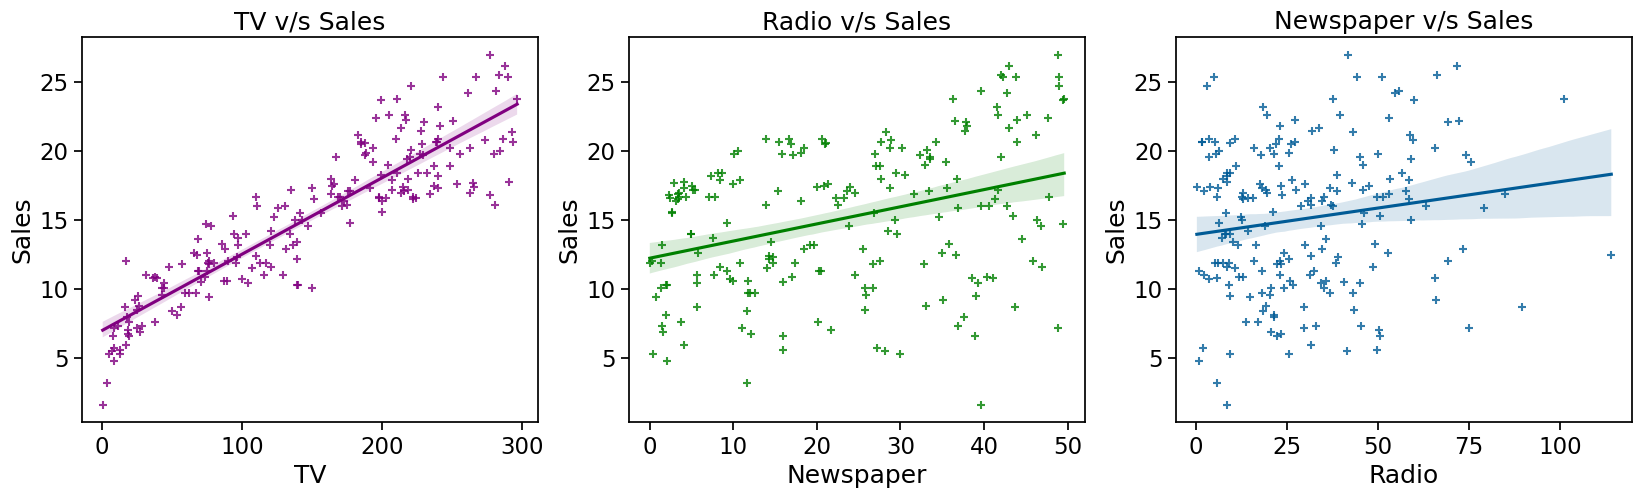

In [16]:
# Regplot of each feature vs target (sales)
sns.set_context('notebook',font_scale = 1.5)
fig, ax = plt.subplots(1, 3, figsize = (20, 5))

sns.regplot(x = df['TV'], y = df['Sales'], color = 'purple', marker = '+', ax = ax[0])
ax[0].set(title = 'TV v/s Sales', xlabel = 'TV', ylabel = 'Sales')

sns.regplot(x = df['Radio'], y = df['Sales'],color = 'green', marker = '+', ax = ax[1])
ax[1].set(title = 'Radio v/s Sales', xlabel = 'Newspaper', ylabel = 'Sales')

sns.regplot(x = df['Newspaper'], y = df['Sales'],marker = '+' ,color = '#005b96', ax = ax[2])
ax[2].set(title = 'Newspaper v/s Sales', xlabel = 'Radio', ylabel = 'Sales')

plt.show()

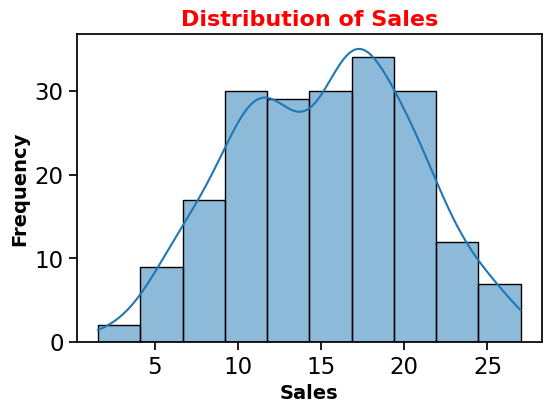

In [17]:
# Target variable distribution
plt.figure(figsize = (6,4))
sns.histplot(df['Sales'], kde = True)
plt.title('Distribution of Sales', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel("Sales", fontsize = 14, fontweight = 'bold')
plt.ylabel("Frequency", fontsize = 14, fontweight = 'bold')
plt.show()

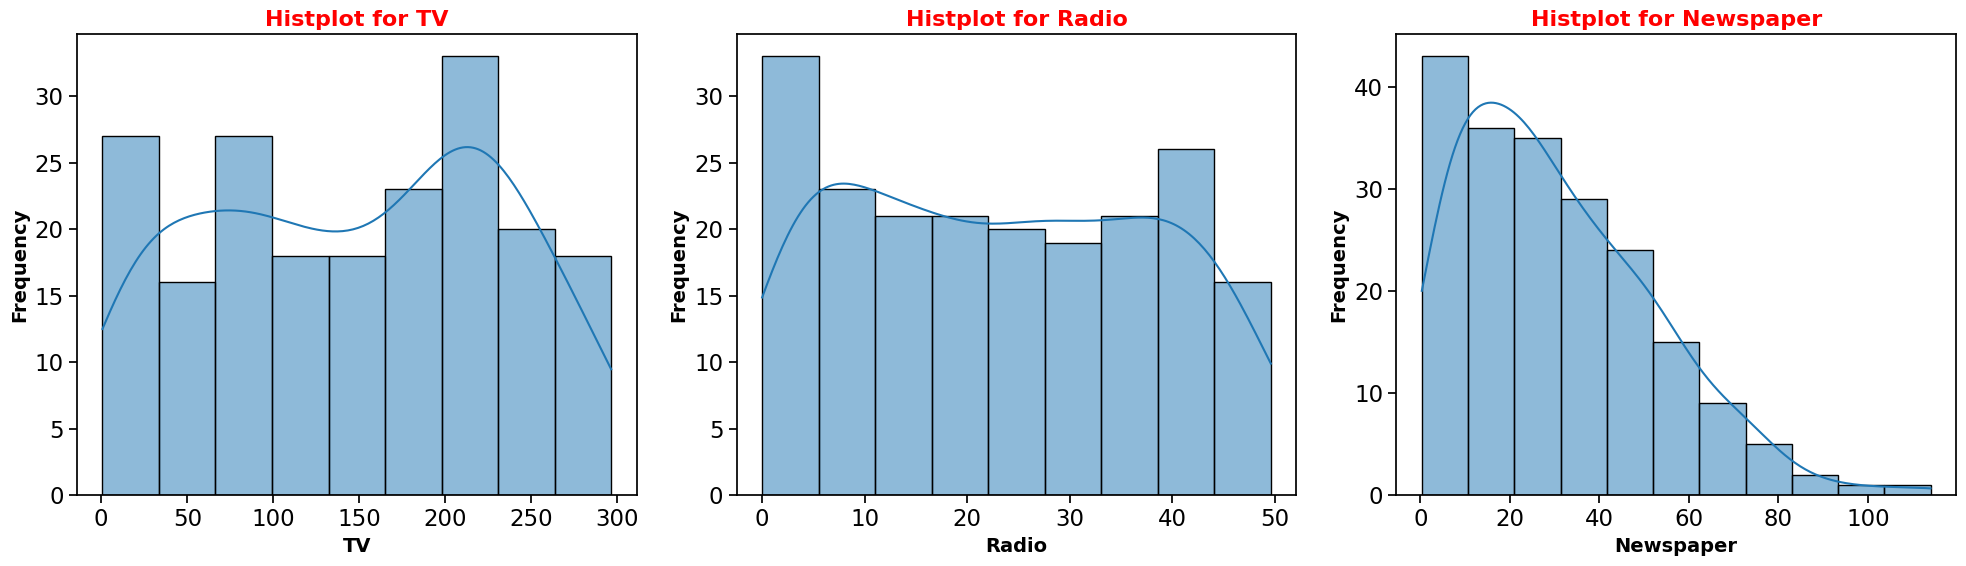

In [18]:
# Histplots for TV, Radio and Newspaper
features = ['TV', 'Radio', 'Newspaper']

fig, axes = plt.subplots(1, 3, figsize = (20, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(x = df[feature], kde = True, ax = ax)
    ax.set_title(f'Histplot for {feature}', fontsize = 16, fontweight = 'bold', color = 'red')
    ax.set_xlabel(feature, fontsize = 14, fontweight = 'bold')
    ax.set_ylabel('Frequency', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

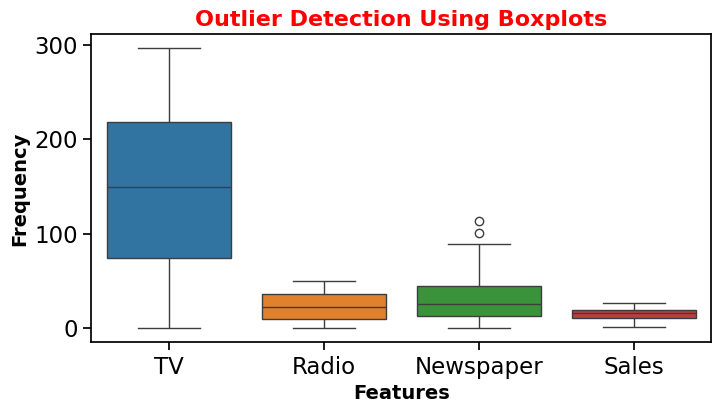

In [19]:
# Boxplot of each variable
plt.figure(figsize = (8,4))
sns.boxplot(data = df[['TV', 'Radio', 'Newspaper', 'Sales']])
plt.title("Outlier Detection Using Boxplots", fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel("Features", fontsize = 14, fontweight = 'bold')
plt.ylabel("Frequency", fontsize = 14, fontweight = 'bold')
plt.show()

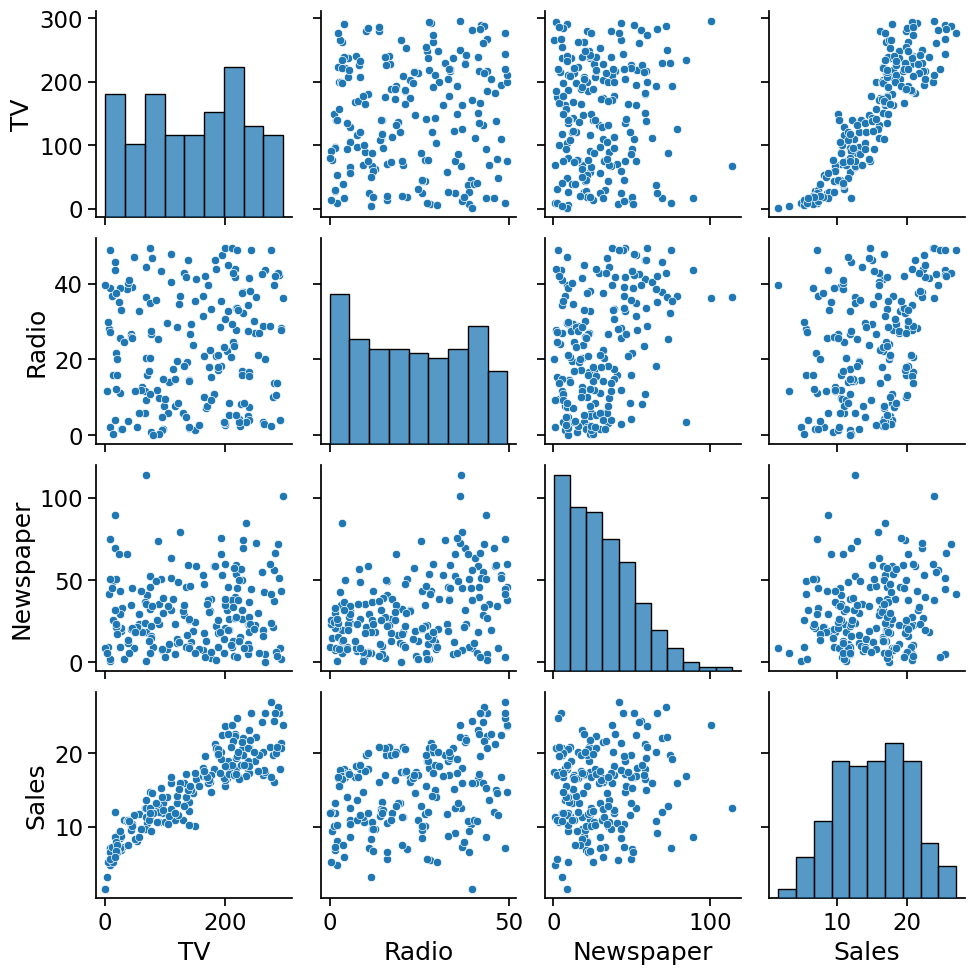

In [20]:
# Pairplot
sns.pairplot(df)
plt.show()

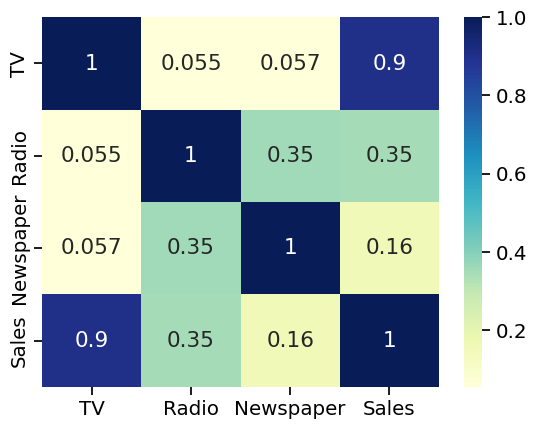

In [21]:
# Heatmap for correlation
sns.set_context('notebook',font_scale = 1.3)
sns.heatmap(df.corr(), cmap = 'YlGnBu', annot = True)
plt.show()

# **Linear Regression Model:**

# **TV v/s Sales:**

In [22]:
X = np.array(df['TV']).reshape(-1,1)
y = np.array(df['Sales'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

# Training the model on the training set
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)

# Predicting the test set results
y_pred = lr.predict(X_test)

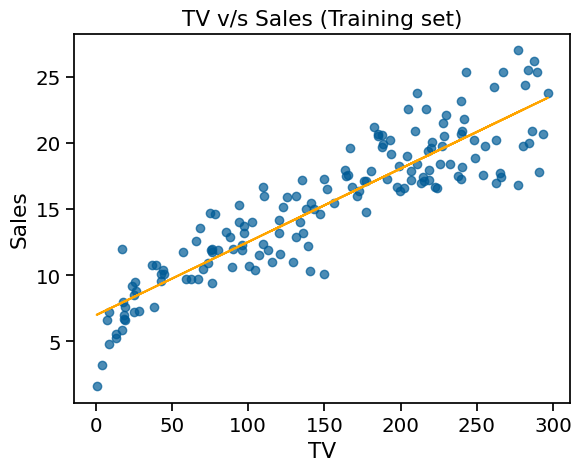

In [23]:
# Visualising training set results
plt.scatter(X_train, y_train, color = '#005b96', alpha= 0.7)
plt.plot(X_train, lr.predict(X_train), color = "orange")
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV v/s Sales (Training set)')
plt.show()

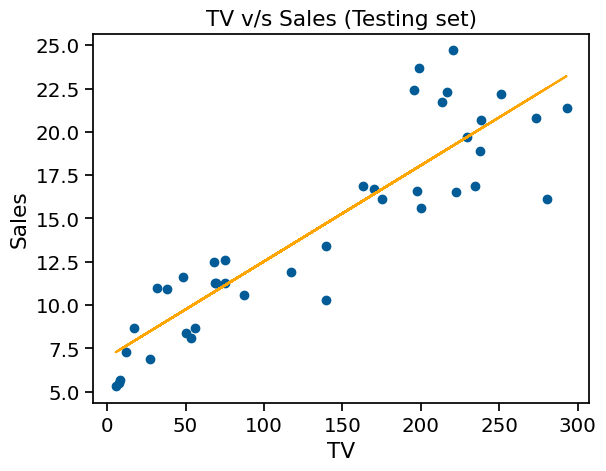

In [24]:
# Visualising test set results
plt.scatter(X_test, y_test, color= '#005b96')
plt.plot(X_test, lr.predict(X_test), color = "orange")
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV v/s Sales (Testing set)')
plt.show()

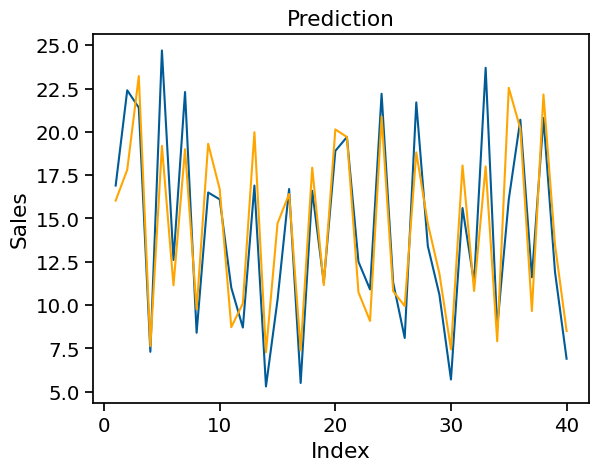

In [25]:
# Plotting predicted value vs Actual value
c = [i for i in range(1, 41, 1)]
plt.plot(c, y_test, color = '#005b96')
plt.plot(c, y_pred, color = 'orange')
plt.xlabel('Index')
plt.ylabel('Sales')
plt.title('Prediction')
plt.show()

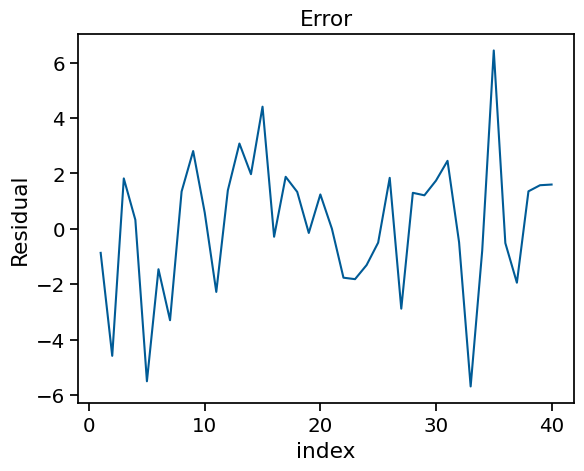

In [26]:
# Plotting the residuals
resid = y_pred - y_test
plt.plot(c, resid, color = '#005b96')
plt.xlabel('index')
plt.ylabel('Residual')
plt.title('Error')
plt.show()

In [27]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr.intercept_, 2))
print('Coefficient of the line:', round(lr.coef_[0], 2))

# Linear Regression Model
slope = lr.coef_[0]
intercept = lr.intercept_
print(f"Sales = {intercept:.3f} + {slope:.3f} * TV")

Root mean square error: 2.467800028212657
R-square: 0.8029184404682554
Intercept of the model: 6.97
Coefficient of the line: 0.06
Sales = 6.975 + 0.055 * TV


# **Radio v/s Sales:**

In [28]:
X = np.array(df['Radio']).reshape(-1,1)
y = np.array(df['Sales'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

# Training the model on the training set
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)

# Predicting the test set results
y_pred = lr.predict(X_test)

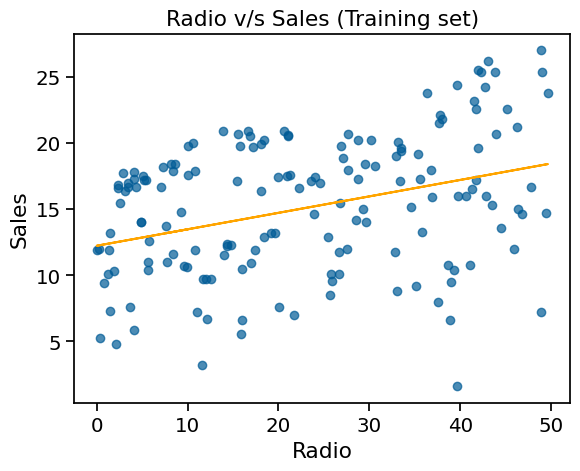

In [29]:
# Visualising training set results
plt.scatter(X_train, y_train, color = '#005b96', alpha= 0.7)
plt.plot(X_train, lr.predict(X_train), color = "orange")
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Radio v/s Sales (Training set)')
plt.show()

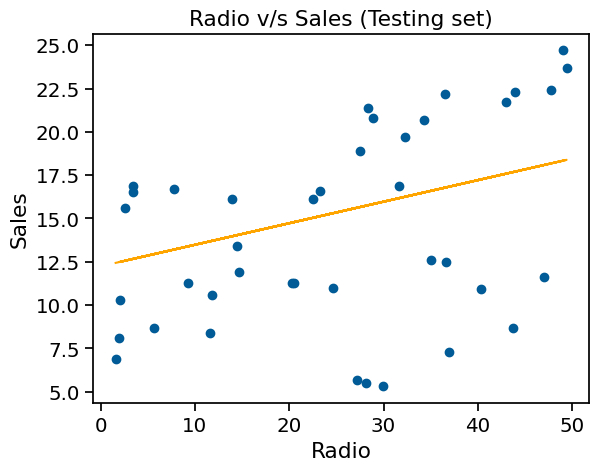

In [30]:
# Visualising test set results
plt.scatter(X_test, y_test, color= '#005b96')
plt.plot(X_test, lr.predict(X_test), color = "orange")
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Radio v/s Sales (Testing set)')
plt.show()

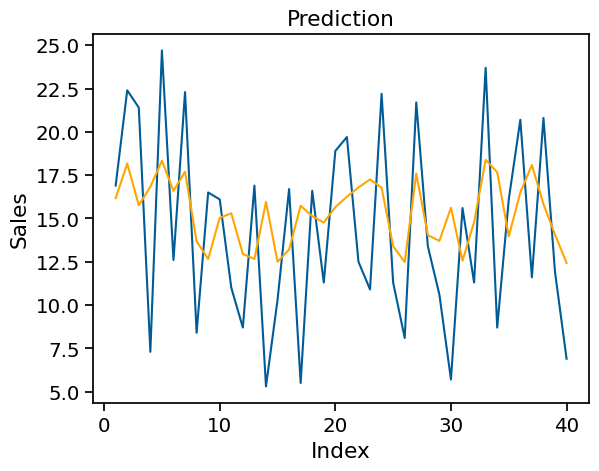

In [31]:
# Plotting predicted value vs Actual value
c = [i for i in range(1, 41, 1)]
plt.plot(c, y_test, color = '#005b96')
plt.plot(c, y_pred, color = 'orange')
plt.xlabel('Index')
plt.ylabel('Sales')
plt.title('Prediction')
plt.show()

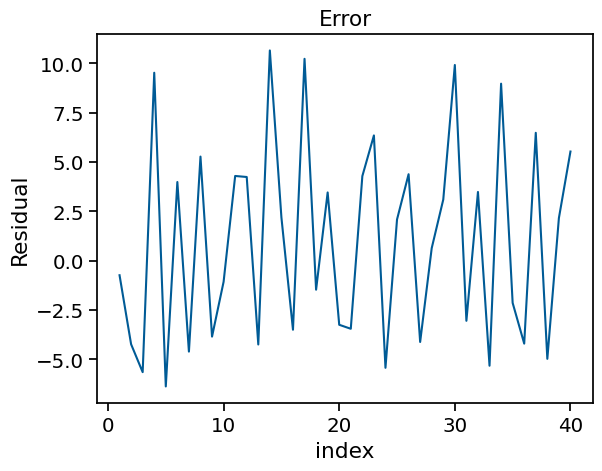

In [32]:
# Plotting the residuals
resid = y_pred - y_test
plt.plot(c, resid, color = '#005b96')
plt.xlabel('index')
plt.ylabel('Residual')
plt.title('Error')
plt.show()

In [33]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr.intercept_, 2))
print('Coefficient of the line:', round(lr.coef_[0], 2))

# Linear Regression Model
slope = lr.coef_[0]
intercept = lr.intercept_
print(f"Sales = {intercept:.3f} + {slope:.3f} * Radio")

Root mean square error: 5.196697136556592
R-square: 0.1260614952511242
Intercept of the model: 12.24
Coefficient of the line: 0.12
Sales = 12.236 + 0.124 * Radio


# **Newspaper v/s Sales:**

In [34]:
X = np.array(df['Newspaper']).reshape(-1,1)
y = np.array(df['Sales'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

# Training the model on the training set
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)

# Predicting the test set results
y_pred = lr.predict(X_test)

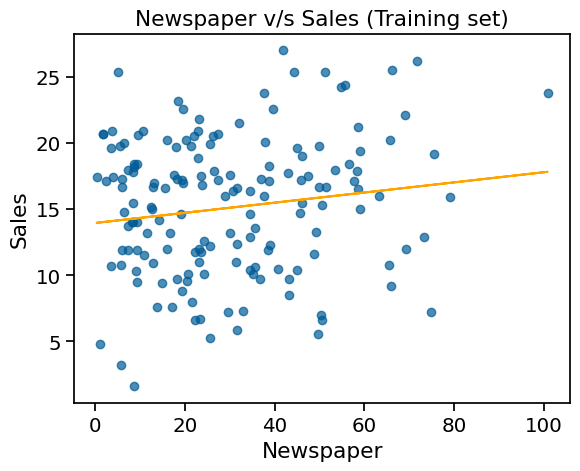

In [35]:
# Visualising training set results
plt.scatter(X_train, y_train, color = '#005b96', alpha= 0.7)
plt.plot(X_train, lr.predict(X_train), color = "orange")
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.title('Newspaper v/s Sales (Training set)')
plt.show()

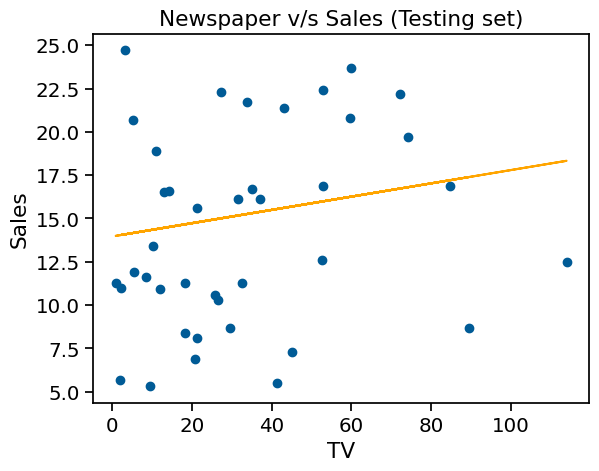

In [36]:
# Visualising test set results
plt.scatter(X_test, y_test, color= '#005b96')
plt.plot(X_test, lr.predict(X_test), color = "orange")
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Newspaper v/s Sales (Testing set)')
plt.show()

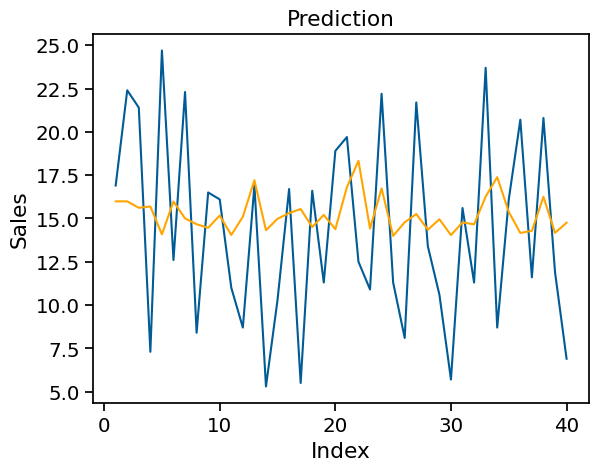

In [37]:
# Plotting predicted value vs Actual value
c = [i for i in range(1, 41, 1)]
plt.plot(c, y_test, color = '#005b96')
plt.plot(c, y_pred, color = 'orange')
plt.xlabel('Index')
plt.ylabel('Sales')
plt.title('Prediction')
plt.show()

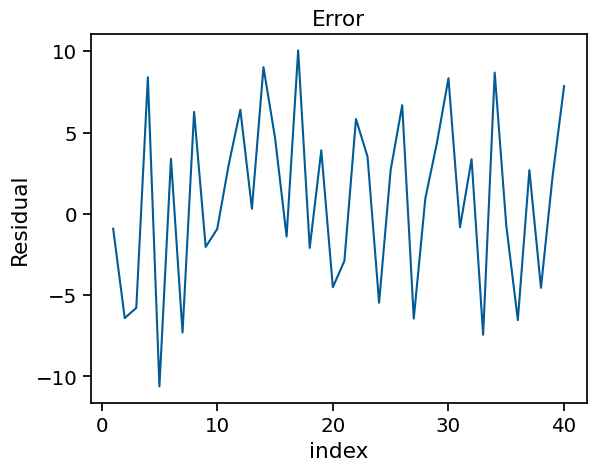

In [38]:
# Plotting the residuals
resid = y_pred - y_test
plt.plot(c, resid, color = '#005b96')
plt.xlabel('index')
plt.ylabel('Residual')
plt.title('Error')
plt.show()

In [39]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr.intercept_, 2))
print('Coefficient of the line:', round(lr.coef_[0], 2))

# Linear Regression Model
slope = lr.coef_[0]
intercept = lr.intercept_
print(f"Sales = {intercept:.3f} + {slope:.3f} * Newspaper")

Root mean square error: 5.505117223739889
R-square: 0.01924799935544086
Intercept of the model: 13.96
Coefficient of the line: 0.04
Sales = 13.960 + 0.038 * Newspaper


# **Multiple Linear Regression:**

In [40]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/advertising.csv")
df.head()

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model on the training set
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Prediction
y_pred = lr_multi.predict(X_test)

In [41]:
# Interpret Coefficients
for feature, coef in zip(X.columns, lr_multi.coef_):
    print(f"{feature}: {coef:.3f}")

TV: 0.055
Radio: 0.101
Newspaper: 0.004


In [42]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr_multi.intercept_, 2))
print('Coefficient of the line:', round(lr_multi.coef_[0], 2))

# Linear Regression Model
coefficients = lr_multi.coef_
intercept = lr_multi.intercept_
feature_names = X_train.columns
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
equation = f"sales = {intercept:.3f}"
for feature, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.3f} * {feature})"

print(equation)

Root mean square error: 1.7052146229349223
R-square: 0.9059011844150826
Intercept of the model: 4.71
Coefficient of the line: 0.05
TV: 0.05450927083721978
Radio: 0.10094536239295579
Newspaper: 0.0043366468220340446
sales = 4.714 + (0.055 * TV) + (0.101 * Radio) + (0.004 * Newspaper)


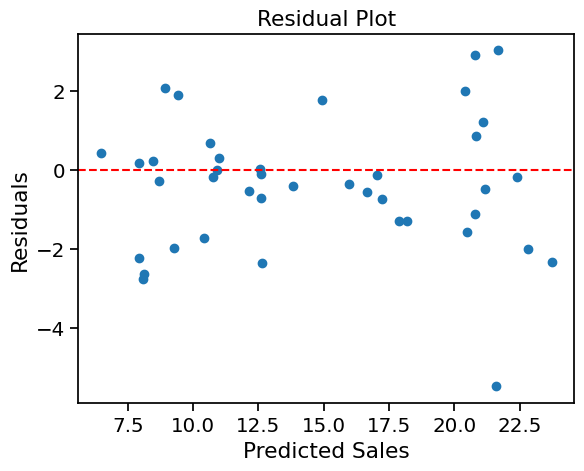

In [43]:
# Residual Diagnostics
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

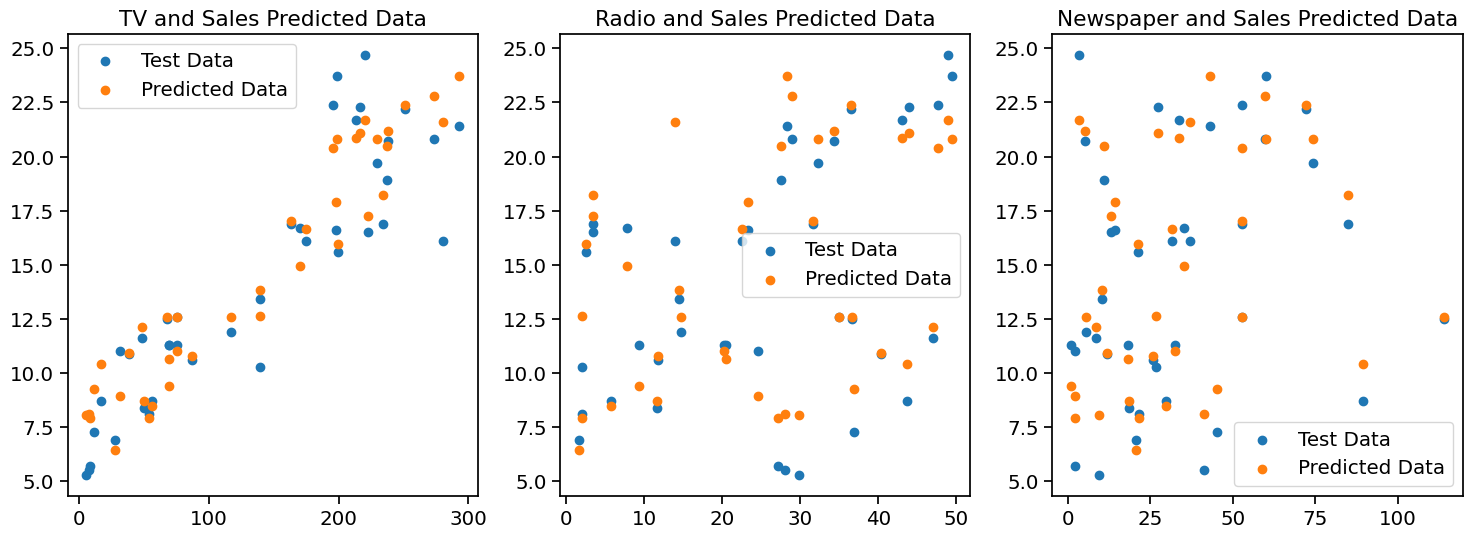

In [44]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(18,6))

ax[0].scatter(X_test['TV'],y_test,label='Test Data')
ax[0].scatter(X_test['TV'],y_pred,label='Predicted Data')
ax[0].set_title('TV and Sales Predicted Data')

ax[1].scatter(X_test['Radio'],y_test,label='Test Data')
ax[1].scatter(X_test['Radio'],y_pred,label='Predicted Data')
ax[1].set_title('Radio and Sales Predicted Data')

ax[2].scatter(X_test['Newspaper'],y_test,label='Test Data')
ax[2].scatter(X_test['Newspaper'],y_pred,label='Predicted Data')
ax[2].set_title('Newspaper and Sales Predicted Data')

ax[0].legend()
ax[1].legend()
ax[2].legend()

# **Making predictions on unseen new data:**

In [45]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/advertising.csv")
df.head()

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Single prediction with input from the user through a prompt
tv = float(input("Enter TV advertising spend: "))
radio = float(input("Enter Radio advertising spend: "))
newspaper = float(input("Enter Newspaper advertising spend: "))

input_data = pd.DataFrame({'TV': [tv], 'Radio': [radio], 'Newspaper': [newspaper]})

prediction = lr.predict(input_data)

print(f"Predicted Sales: {prediction[0]:.2f}")

Enter TV advertising spend: 30
Enter Radio advertising spend: 10
Enter Newspaper advertising spend: 20
Predicted Sales: 7.45


In [46]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/advertising.csv")
df.head()

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Multiple predictions at once
input_data = pd.DataFrame({'TV':[10,76,53,124,108,21],'Radio':[34,53,13,100,29,82],'Newspaper':[97,81,49,18,31,62]})

predictions = lr.predict(input_data)
print(f"Predicted Sales: {predictions[0]:.2f}")

Predicted Sales: 9.11


# **Feature selection experiment:**

Drop one feature and train the model on the remaining two features

# **Drop Newspaper:**

In [47]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/advertising.csv")
df.head()

df = df.drop('Newspaper', axis = 1)
X = df[['TV', 'Radio']]
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model on the training set
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Prediction
y_pred = lr_multi.predict(X_test)

In [48]:
# Interpret Coefficients
for feature, coef in zip(X.columns, lr_multi.coef_):
    print(f"{feature}: {coef:.3f}")

TV: 0.055
Radio: 0.103


In [49]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr_multi.intercept_, 2))
print('Coefficient of the line:', round(lr_multi.coef_[0], 2))

# Linear Regression Model
coefficients = lr_multi.coef_
intercept = lr_multi.intercept_
feature_names = X_train.columns
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
equation = f"sales = {intercept:.3f}"
for feature, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.3f} * {feature})"

print(equation)

Root mean square error: 1.6871917858179433
R-square: 0.9078797802624651
Intercept of the model: 4.79
Coefficient of the line: 0.05
TV: 0.05450736175135675
Radio: 0.10325763756778356
sales = 4.791 + (0.055 * TV) + (0.103 * Radio)


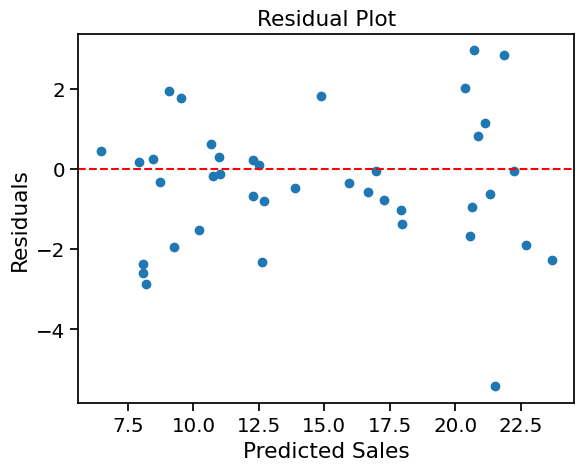

In [50]:
# Residual Diagnostics
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# **Drop Radio:**

In [51]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/advertising.csv")
df.head()

df = df.drop('Radio', axis = 1)
X = df[['TV', 'Newspaper']]
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model on the training set
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Prediction
y_pred = lr_multi.predict(X_test)

In [52]:
# Interpret Coefficients
for feature, coef in zip(X.columns, lr_multi.coef_):
    print(f"{feature}: {coef:.3f}")

TV: 0.055
Newspaper: 0.033


In [53]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr_multi.intercept_, 2))
print('Coefficient of the line:', round(lr_multi.coef_[0], 2))

# Linear Regression Model
coefficients = lr_multi.coef_
intercept = lr_multi.intercept_
feature_names = X_train.columns
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
equation = f"sales = {intercept:.3f}"
for feature, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.3f} * {feature})"

print(equation)

Root mean square error: 2.5291509947597093
R-square: 0.7929975064222947
Intercept of the model: 6.05
Coefficient of the line: 0.06
TV: 0.05533219048934068
Newspaper: 0.03279089003195726
sales = 6.048 + (0.055 * TV) + (0.033 * Newspaper)


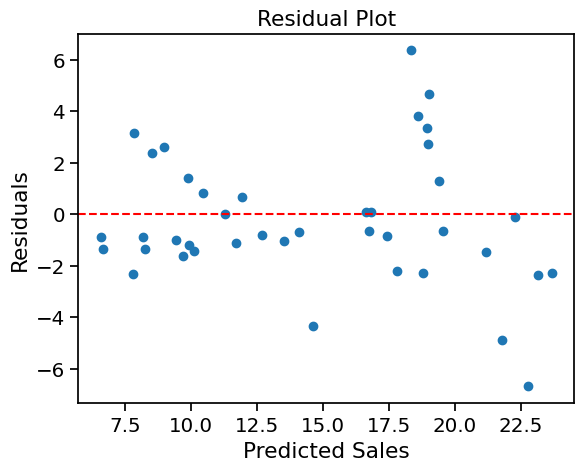

In [54]:
# Residual Diagnostics
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# **Drop TV:**

In [55]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/advertising.csv")
df.head()

df = df.drop('TV', axis = 1)
X = df[['Radio', 'Newspaper']]
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model on the training set
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Prediction
y_pred = lr_multi.predict(X_test)

In [56]:
# Interpret Coefficients
for feature, coef in zip(X.columns, lr_multi.coef_):
    print(f"{feature}: {coef:.3f}")

Radio: 0.118
Newspaper: 0.004


In [57]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr_multi.intercept_, 2))
print('Coefficient of the line:', round(lr_multi.coef_[0], 2))

# Linear Regression Model
coefficients = lr_multi.coef_
intercept = lr_multi.intercept_
feature_names = X_train.columns
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
equation = f"sales = {intercept:.3f}"
for feature, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.3f} * {feature})"

print(equation)

Root mean square error: 5.244104485031301
R-square: 0.1100435955378477
Intercept of the model: 12.52
Coefficient of the line: 0.12
Radio: 0.11794819386536104
Newspaper: 0.0038512501428229276
sales = 12.517 + (0.118 * Radio) + (0.004 * Newspaper)


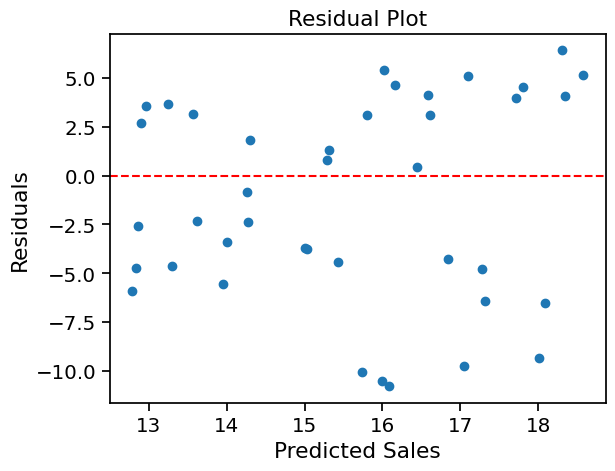

In [58]:
# Residual Diagnostics
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# **Insights and Recommendations:**

- TV advertising is the most effective channel for driving sales and should receive priority in budget allocation.
- Radio advertising contributes positively to sales and performs best as a complementary channel.
- Newspaper advertising shows minimal impact and may be deprioritized in favor of higher-ROI channels.
- The model highlights diminishing returns, suggesting the importance of optimizing spend rather than maximizing it.
- The regression model can be used as a decision-support tool to forecast sales under different advertising strategies.